<mark><font color=black size=5>**Group Component 1**</font><mark>

<mark><font color=black size=3>**Preliminary Changes to Data**</font><mark>

In [1]:
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
import numpy as np

In [2]:
# read csv file
df = pd.read_csv('player_score_regression.csv')
df.head()

/var/folders/dj/hp4tkwp92wl70mh7j8_5m40c0000gn/T/ipykernel_82241/3550940504.py:2: DtypeWarning: Columns (77) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('player_score_regression.csv')


,Unnamed: 0,PlayerID,PlayerName,FullName,PhotoURL,PlayerURL,Country,Age,Rating in Scale 100,Potential in Scale 100,...,AttackingWorkRate,DefensiveWorkRate,InternationalReputation,Pace,Shooting,Passing,Dribbling.1,Defending,Physical,PopularityHits
0,0,158023,L. Messi,Lionel Messi,https://cdn.sofifa.com/players/158/023/21_60.png,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,33,93,93,...,Medium,Low,5 ★,85,92,91,95,38,65,771
1,1,20801,Cristiano Ronaldo,C. Ronaldo dos Santos Aveiro,https://cdn.sofifa.com/players/020/801/21_60.png,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,35,92,92,...,High,Low,5 ★,89,93,81,89,35,77,562
2,2,200389,J. Oblak,Jan Oblak,https://cdn.sofifa.com/players/200/389/21_60.png,http://sofifa.com/player/200389/jan-oblak/210006/,Slovenia,27,91,93,...,Medium,Medium,3 ★,87,92,78,90,52,90,150
3,3,192985,K. De Bruyne,Kevin De Bruyne,https://cdn.sofifa.com/players/192/985/21_60.png,http://sofifa.com/player/192985/kevin-de-bruyn...,Belgium,29,91,91,...,High,High,4 ★,76,86,93,88,64,78,207
4,4,190871,Neymar Jr,Neymar da Silva Santos Jr.,https://cdn.sofifa.com/players/190/871/21_60.png,http://sofifa.com/player/190871/neymar-da-silv...,Brazil,28,91,91,...,High,Medium,5 ★,91,85,86,94,36,59,595


<font color=black size=2>**Since one feature in the raw dataset (which is also the feature we will be predicting) is ‘Potential in Scale 100,’ but there are values greater than 100 in the dataset, we need to remove the data where the values exceed 100.**</font>

In [3]:
# dropping all cells that values is over 100 
df = df[df['Rating in Scale 100'] <= 100]
df = df[df['Potential in Scale 100'] <= 100]

In [4]:
# Find all null values in percentage. This step helps to drop unecessary columns.
null_columns=df.columns[df.isnull().any()]
df[null_columns].isnull().sum()/len(df)*100 

LoanEndDate       94.600039
PopularityHits    13.685100
dtype: float64

In [5]:
# 'InternationalReputation' have 6 unique values, find every value that not in valid_reputaionand and delete that rows. 
#We can't use 0 values in our research, because these data cannot be recovered and unuseful.
valid_reputations = {'5 ★', '4 ★', '3 ★', '2 ★', '1 ★'}
df = df[df['InternationalReputation'].isin(valid_reputations)]

<font color=black size=2>**The data we are predicting is ‘Potential in Scale 100.’ Next, we removed several irrelevant columns to obtain a more precise dataset. We also noticed that the NA values in ‘PopularityHits’ are concentrated among lower-value players, and the entire column does not contain the value 0. Therefore, we reasonably assume that the missing values in this column are 0, so we filled the missing values with 0.**</font>

In [6]:
# Drop some usless columns for Rating prediction
columns_to_drop = ['Unnamed: 0','PlayerID','PlayerName','FullName','PhotoURL','PlayerURL','Country','CurrentClub','ContractInfo','PlayingPositions',
                   'DateJoined','LoanEndDate','Height','Weight','PopularityHits',
                   'CrossingAbility','FinishingAbility','HeadingAccuracy','ShortPassing','Volleys',
                   'Dribbling','CurveAbility','FreeKickAccuracy','LongPassing','BallControl',
                   'Acceleration','SprintSpeed','Agility','Reactions','Balance',
                   'ShotPower','JumpingAbility','Stamina','Strength','LongShots',
                   'Aggression','Interceptions','Positioning','Vision','Penalties',
                   'Marking','StandingTackle','SlidingTackle',
                   'GoalkeeperDiving','GoalkeeperHandling','GoalkeeperKicking','GoalkeeperPositioning','GoalkeeperReflexes'
                  ]
df = df.drop(columns=columns_to_drop)

In [7]:
# ‘shooting’ column is still of object type, so we need to drop them
df['Shooting'] = pd.to_numeric(df['Shooting'], errors='coerce')
df = df.dropna(subset=['Shooting'])

In [8]:
# Numericalize the MarketValue column
df['MarketValue'] = df['MarketValue'].replace({'€': ''}, regex=True)    # Remove currency symbol
df['WeeklyWage'] = df['WeeklyWage'].replace({'€': ''}, regex=True)
df['ReleaseClause'] = df['ReleaseClause'].replace({'€': ''}, regex=True)

# Define type conversion function
def convert_market_value(x):
    # If it is a string and contains 'M'
    if isinstance(x, str) and 'M' in x:
        return float(x.replace('M', '')) * 1e6
    
    # If it is a string and contains 'K'
    elif isinstance(x, str) and 'K' in x:
        return float(x.replace('K', '')) * 1e3
    
    # Else, convert directly to a float
    else:
        return float(x)

df['MarketValue'] = df['MarketValue'].apply(convert_market_value)
df['WeeklyWage'] = df['WeeklyWage'].apply(convert_market_value)
df['ReleaseClause'] = df['ReleaseClause'].apply(convert_market_value)

<mark><font color=black size=2>**The above code is the code we ran in Assignment 1, and we obtained the dataset for our Assignment 1.**</font><mark>

<mark><font color=black size=2>**Next is the further processing of the dataset for Assignment 2.**</font><mark>

In [9]:
# Convert elements containing ★ in the column to numeric type

df['WeakFoot'] = df['WeakFoot'].apply(lambda x: int(str(x)[0]))
df['SkillMoves'] = df['SkillMoves'].apply(lambda x: int(str(x)[0]))
df['InternationalReputation'] = df['InternationalReputation'].apply(lambda x: int(str(x)[0]))

<mark><font color=black size=3>**Data split for train/validation/test sets**</font><mark>

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split

y = df['Rating in Scale 100']
X = df.drop(df.columns[[0, df.columns.get_loc('Rating in Scale 100')]], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5310)

<font color=black size=2>**Standardize the numerical data after splitting the dataset, because if standardization is done before the split, the validation and test sets may observe the data from the training set, leading to information leakage. Below, the training set, validation set, and test set are standardized separately. At the same time, we used one-hot encoding to process the categorical data to improve the model’s prediction.**</font>

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

# Define categorical features
categorical_features = ['PreferredFoot', 'BestPosition', 'WeakFoot', 'SkillMoves', 'AttackingWorkRate', 'DefensiveWorkRate', 'InternationalReputation']

# Define numerical features
X_train_num = X_train.drop(columns=categorical_features)
X_test_num = X_test.drop(columns=categorical_features)

# Standardize the numerical features
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num)  # standardization on training set
X_test_num_scaled = scaler.transform(X_test_num)        # standardization on test set

# Perform one-hot encoding on categorical data
encoder = OneHotEncoder()
X_train_cat = encoder.fit_transform(X_train[categorical_features])
X_test_cat = encoder.transform(X_test[categorical_features])

# Concatenate the one-hot encoded data with other numerical features
X_train_encoded = np.hstack((X_train_cat.toarray(), X_train_num_scaled))
X_test_encoded = np.hstack((X_test_cat.toarray(), X_test_num_scaled))

<mark><font color=black size=5>**Individual Component**</font><mark>

<mark><font size=3>Title: Perform regression analysis using Linear regression</font><mark><p>

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model_lr = LinearRegression()

# Train the model on the training data
model_lr.fit(X_train_encoded, y_train)

# Make predictions on the test data
y_test_pred_lr = model_lr.predict(X_test_encoded)

# Evaluate the model
mse_lr = mean_squared_error(y_test, y_test_pred_lr)  # Mean Squared Error
r2_lr = r2_score(y_test, y_test_pred_lr)  # R-squared value

# Output the results
print(f"Mean Squared Error: {mse_lr}")
print(f"R-squared value: {r2_lr}")


Mean Squared Error: 6.2812656548544865
R-squared value: 0.8750500445932348


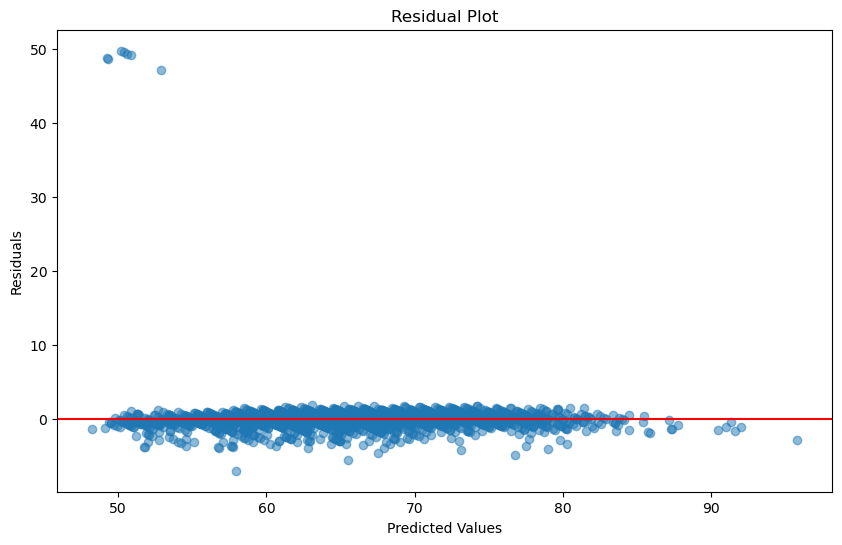

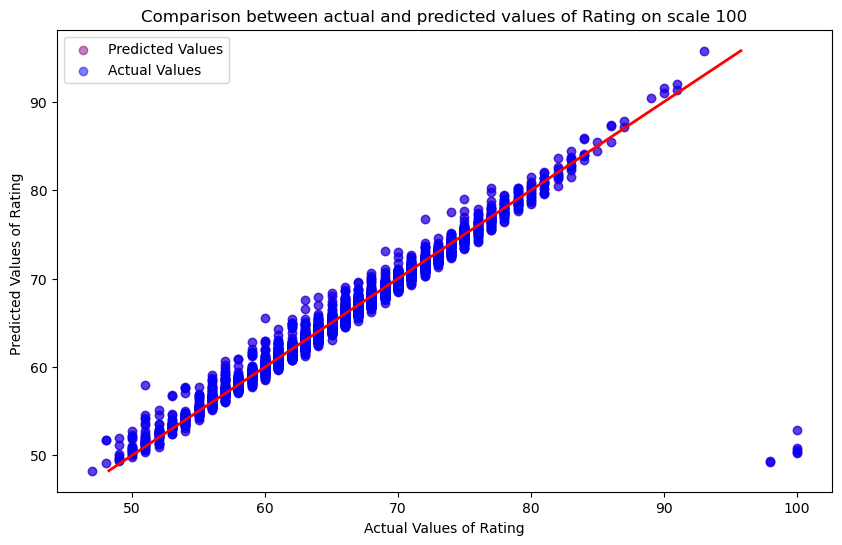

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Plot 1: Residual Plot
plt.figure(figsize=(10, 6))
residuals = y_test - y_test_pred_lr
plt.scatter(y_test_pred_lr, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='-')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

# Plot 2: Predicted vs Actual Values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred_lr, alpha=0.5, color='purple', label='Predicted Values')
plt.scatter(y_test, y_test_pred_lr, alpha=0.5, color='blue', label='Actual Values')
plt.plot([y_test_pred_lr.min(), y_test_pred_lr.max()], [y_test_pred_lr.min(), y_test_pred_lr.max()], color='red', linewidth=2, linestyle='-')
plt.xlabel('Actual Values of Rating')
plt.ylabel('Predicted Values of Rating ')
plt.title('Comparison between actual and predicted values of Rating on scale 100')
plt.legend()
plt.show()


In [14]:
from sklearn.decomposition import PCA

# Set up PCA to retain 95% of variance
pca = PCA(n_components=0.95)

# Fit PCA on the training data and transform both training and test sets
X_train_pca = pca.fit_transform(X_train_encoded)
X_test_pca = pca.transform(X_test_encoded)

# Train the Linear Regression model using the PCA-transformed data
model_pca = LinearRegression()
model_pca.fit(X_train_pca, y_train)

# Make predictions using the PCA-transformed test data
y_test_pred_pca = model_pca.predict(X_test_pca)

# Evaluate the optimized model with PCA
mse_pca = mean_squared_error(y_test, y_test_pred_pca)  # Mean Squared Error
r2_pca = r2_score(y_test, y_test_pred_pca)  # R-squared value

print(f"Mean Squared Error with PCA: {mse_pca}")
print(f"R-squared value with PCA: {r2_pca}")
print(f"Intercept: {model_pca.intercept_}")
print(f"Coefficients: {model_pca.coef_}")

Mean Squared Error with PCA: 7.6174384093797665
R-squared value with PCA: 0.8484702539479151
Intercept: 65.76055528174798
Coefficients: [ 1.75356364  1.03288761  1.33707883 -0.95086807 -0.01551542  0.68861062
  1.2001066  -0.55348174 -0.37522901  0.51069139  1.50585668  0.23049359
  0.10678696  0.09900718  1.71911419 -1.27450169  3.12608484]


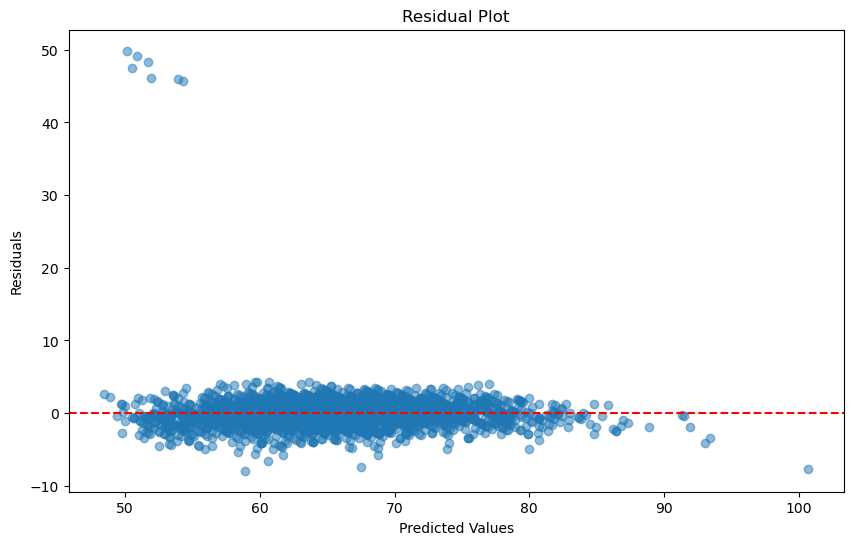

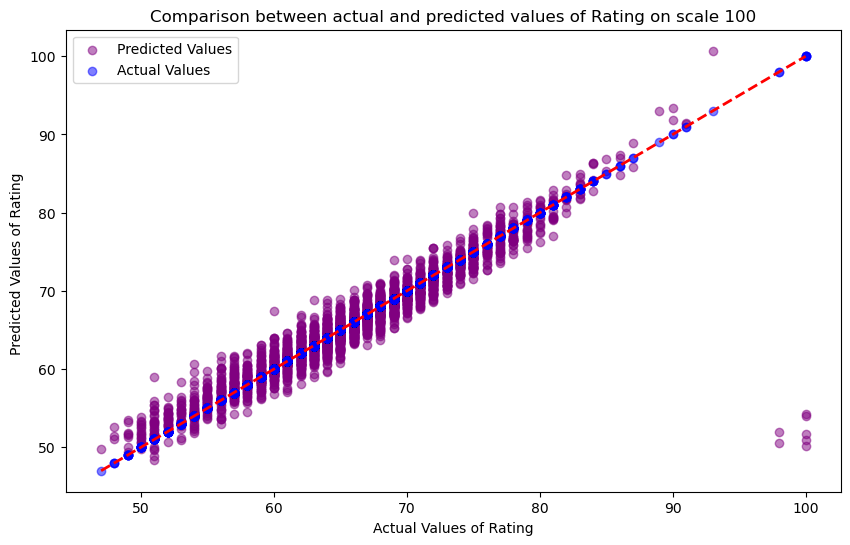

In [15]:
#PCA applied
# Plot 1: Residual Plot
plt.figure(figsize=(10, 6))
residuals = y_test - y_test_pred_pca
plt.scatter(y_test_pred_pca, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

# Plot 2: Predicted vs Actual Values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred_pca, alpha=0.5, color='purple', label='Predicted Values')
plt.scatter(y_test, y_test, alpha=0.5, color='blue', label='Actual Values')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2, linestyle='--')
plt.xlabel('Actual Values of Rating')
plt.ylabel('Predicted Values of Rating ')
plt.title('Comparison between actual and predicted values of Rating on scale 100')
plt.legend()
plt.show()

In [16]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
import time

param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}
ridge = Ridge()
grid_search = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_test_encoded, y_test)
best_alpha = grid_search.best_params_['alpha']
print(f"Optimal alpha: {best_alpha}")
ridge_optimized = Ridge(alpha=best_alpha)
ridge_optimized.fit(X_train_encoded, y_train)

# start time
start_time = time.time()

y_test_pred_optimized = ridge_optimized.predict(X_test_encoded)

# End time
end_time = time.time()

# Calculate time
prediction_time_lr = end_time - start_time

mse_optimized = mean_squared_error(y_test, y_test_pred_optimized)
r2_optimized = r2_score(y_test, y_test_pred_optimized)
print(f"Optimized Mean Squared Error: {mse_optimized}")
print(f"Optimized R-squared value: {r2_optimized}")

Optimal alpha: 10
Optimized Mean Squared Error: 6.2810759277926795
Optimized R-squared value: 0.8750538187351378


<mark><font size=3>Title: Perform regression analysis using SVM</font><mark><p>

<font color=black size=2>**Perform dimensionality reduction using PCA.**</font>

In [17]:
from sklearn.decomposition import PCA

# Perform dimensionality reduction using PCA.
pca = PCA(n_components=0.98)
X_train_pca = pca.fit_transform(X_train_encoded)
X_test_pca = pca.transform(X_test_encoded)

In [18]:
from sklearn.svm import LinearSVR
from sklearn.metrics import mean_squared_error, r2_score

# upload LinearSVR model(linear model of SVM)
linear_svr = LinearSVR()

# fitting on the training set
linear_svr.fit(X_train_pca, y_train)

# predicting on the validation set
y_test_pred_svr = linear_svr.predict(X_test_pca)

# Evaluate the model
mse_svr = mean_squared_error(y_test, y_test_pred_svr)
r2_svr = r2_score(y_test, y_test_pred_svr)

# Output the results
print(f"Mean Squared Error: {mse_svr}")
print(f"R-squared value: {r2_svr}")

Mean Squared Error: 6.962467202869476
R-squared value: 0.8614992559903502


/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [19]:
from sklearn.model_selection import GridSearchCV

# Define the range of parameters to search
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100], 
    'epsilon': [0.001, 0.01, 0.1, 0.5, 1]
}

# upload LinearSVR model
linear_svr = LinearSVR(random_state=5310)

# Use GridSearchCV for hyperparameter tuning
grid_search_svr = GridSearchCV(linear_svr, param_grid, scoring='neg_mean_squared_error', cv=5, n_jobs=-1)

# Perform the search on the training set
grid_search_svr.fit(X_train_pca, y_train)

# Output the best parameters
print(f"Best parameters: {grid_search_svr.best_params_}")

# Use the best parameters for prediction
best_linear_svr = grid_search_svr.best_estimator_

# Start time
start_time = time.time()

y_best_test_pred_svr = best_linear_svr.predict(X_test_pca)

# End time
end_time = time.time()

# Calculate time
prediction_time_svr = end_time - start_time

/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the n

Best parameters: {'C': 1, 'epsilon': 1}


/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [20]:
# Evaluate the best model
mse_best_svr = mean_squared_error(y_test, y_best_test_pred_svr)
r2_best_svr = r2_score(y_test, y_best_test_pred_svr)

# Output the results
print(f"Mean Squared Error: {mse_best_svr}")
print(f"R-squared value: {r2_best_svr}")

Mean Squared Error: 6.944872063031415
R-squared value: 0.8618492669688609


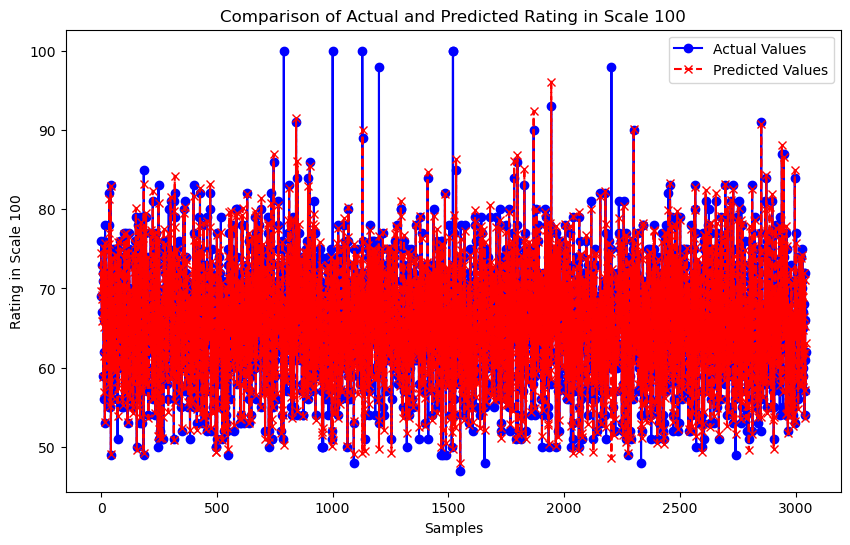

In [21]:
import matplotlib.pyplot as plt

# The x-axis represents the sample index
x_axis = np.arange(len(y_test))

# Create a line chart to compare the actual values and predicted values
plt.figure(figsize=(10, 6))
plt.plot(x_axis, y_test, label='Actual Values', color='blue', marker='o')
plt.plot(x_axis, y_best_test_pred_svr, label='Predicted Values', color='red', linestyle='--', marker='x')

# Set the label
plt.title('Comparison of Actual and Predicted Rating in Scale 100')
plt.xlabel('Samples')
plt.ylabel('Rating in Scale 100')
plt.legend()

plt.show()

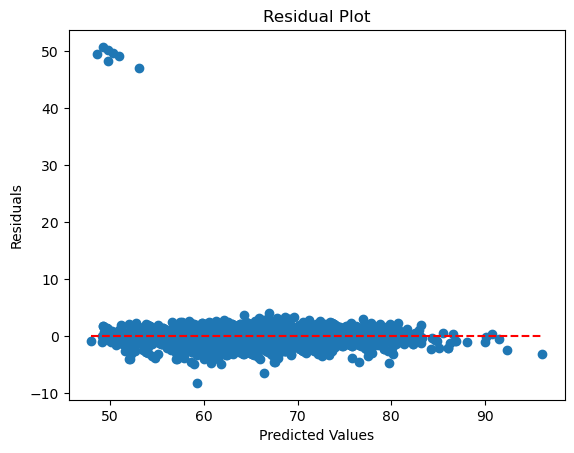

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate residuals
residuals_svr = y_test - y_best_test_pred_svr

# Make residual plot
plt.scatter(y_best_test_pred_svr, residuals_svr)
plt.hlines(0, min(y_best_test_pred_svr), max(y_best_test_pred_svr), color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

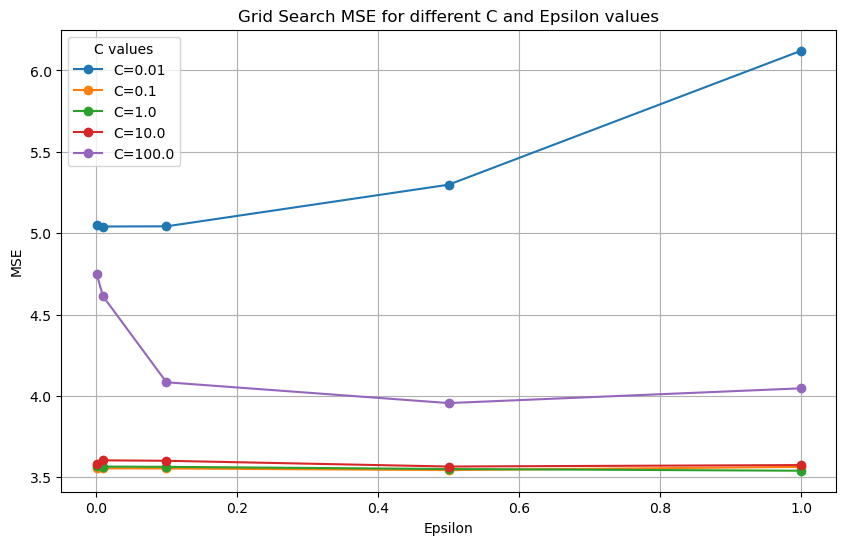

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Get the GridSearchCV results.
results = grid_search_svr.cv_results_

# Extract the MSE values for the ‘C’ and ‘epsilon’ parameter combinations.
mean_test_scores = -results['mean_test_score']  # In GridSearch, the mean test score’s MSE is negative.
C_values = [param['C'] for param in grid_search_svr.cv_results_['params']]
epsilon_values = [param['epsilon'] for param in grid_search_svr.cv_results_['params']]

# Plot a line chart of MSE for each parameter combination.
plt.figure(figsize=(10, 6))

for C in np.unique(C_values): 
    idx = np.array(C_values) == C  # Get the index of C
    epsilon_subset = np.array(epsilon_values)[idx]  # Get the epsilon based on the index
    mse_subset = np.array(mean_test_scores)[idx]  # Get the MSE based on the index
    plt.plot(epsilon_subset, mse_subset, marker='o', label=f'C={C}')
    
plt.xlabel('Epsilon')
plt.ylabel('MSE')
plt.title('Grid Search MSE for different C and Epsilon values')
plt.legend(title='C values')
plt.grid(True)
plt.show()

<mark><font size=3>Title: Perform regression analysis using RandomForestRegressor model</font><mark><p>

In [24]:
# Import necessary libraries
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

# Create a copy of the dataframe to avoid modifying the source data
X_train_copy = X_train.copy()
X_test_copy = X_test.copy()

# Initialize LabelEncoder for the 'BestPosition' column
le = LabelEncoder()

# Transform the 'BestPosition' column from categorical to numerical values
X_train_copy['BestPosition'] = le.fit_transform(X_train_copy['BestPosition'])
X_test_copy['BestPosition'] = le.fit_transform(X_test_copy['BestPosition'])

# Replace 'AttackingWorkRate' and 'DefensiveWorkRate' categorical values with numerical equivalents
X_train_copy['AttackingWorkRate'] = X_train_copy['AttackingWorkRate'].replace({'Low': 1, 'Medium': 2, 'High': 3})
X_train_copy['DefensiveWorkRate'] = X_train_copy['DefensiveWorkRate'].replace({'Low': 1, 'Medium': 2, 'High': 3})
X_test_copy['AttackingWorkRate'] = X_test_copy['AttackingWorkRate'].replace({'Low': 1, 'Medium': 2, 'High': 3})
X_test_copy['DefensiveWorkRate'] = X_test_copy['DefensiveWorkRate'].replace({'Low': 1, 'Medium': 2, 'High': 3})

# Replace 'PreferredFoot' categorical values ('Left', 'Right') with numerical values (0 for 'Left', 1 for 'Right')
X_train_copy['PreferredFoot'] = X_train_copy['PreferredFoot'].replace({'Left': 0, 'Right': 1})
X_test_copy['PreferredFoot'] = X_test_copy['PreferredFoot'].replace({'Left': 0, 'Right': 1})

# Initialize the RandomForestRegressor model with specific hyperparameters
# n_estimators: number of trees (100), max_depth: maximum depth of trees (20),
# min_samples_leaf: minimum samples required to be at a leaf node (1),
# min_samples_split: minimum samples required to split a node (2)
rf = RandomForestRegressor(n_estimators=100, max_depth=20, min_samples_leaf=1, min_samples_split=2, random_state=5310)

# Train the RandomForestRegressor model on the training data
rf.fit(X_train_copy, y_train)

# Use the trained model to make predictions on the test data
y_pred_rf = rf.predict(X_test_copy)

# Calculate the Mean Squared Error (MSE) between the predicted and actual test values
mse = mean_squared_error(y_test, y_pred_rf)
print(f'Mean Squared Error (MSE): {mse}')

# Calculate the R-squared (R²) score to assess the goodness of fit of the model
r2 = r2_score(y_test, y_pred_rf)
print(f'R-squared (R²): {r2}')

Mean Squared Error (MSE): 5.467545720688349
R-squared (R²): 0.8912369526265027


In [25]:
# Define a smaller parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5], 
    'min_samples_leaf': [1, 2]  
}

# Initialize RandomForestRegressor
rf = RandomForestRegressor(random_state=5310)

# Initialize GridSearchCV with 5-fold cross-validation
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Fit the model on the training data
grid_search_rf.fit(X_train_copy, y_train)

# Output the best hyperparameter combination
print(f"Best parameters: {grid_search_rf.best_params_}")

# Use the best model to make predictions
best_rf = grid_search_rf.best_estimator_

# Start time
start_time = time.time()

y_best_pred_rf = best_rf.predict(X_test_copy)

# End time
end_time = time.time()

# Calculate time
prediction_time_rf = end_time - start_time

# Calculate Mean Squared Error (MSE) on the test data
mse_best_rf = mean_squared_error(y_test, y_best_pred_rf)

# Calculate R-squared (R²) score to assess model's goodness of fit
r2_best_rf = r2_score(y_test, y_best_pred_rf)

# Output the performance metrics
print(f'Mean Squared Error (MSE): {mse_best_rf}')
print(f'R-squared (R²): {r2_best_rf}')

Best parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Mean Squared Error (MSE): 5.436546185294601
R-squared (R²): 0.891853610284038


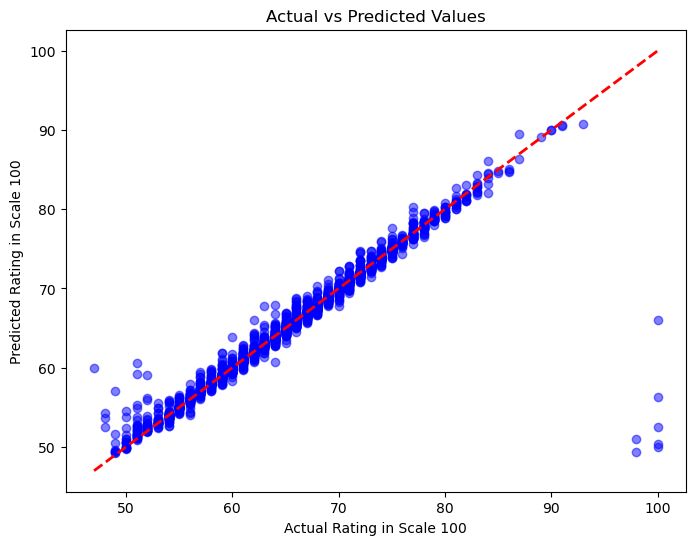

In [26]:
import matplotlib.pyplot as plt

# Create a scatter plot of actual values vs predicted values
plt.figure(figsize=(8, 6))  # Set the figure size

# Scatter plot of actual vs predicted values
plt.scatter(y_test, y_best_pred_rf, alpha=0.5, color='blue')  # alpha adjusts the transparency of the points (0.5 = 50% transparency)

# Plot a 45-degree reference line (ideal line where actual = predicted)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # 'r--' is a dashed red line, lw=2 sets the line width

# Set labels for the X and Y axes
plt.xlabel('Actual Rating in Scale 100')  # X-axis label: Actual values
plt.ylabel('Predicted Rating in Scale 100')  # Y-axis label: Predicted values

# Set the title of the plot
plt.title('Actual vs Predicted Values')

# Display the plot
plt.show()


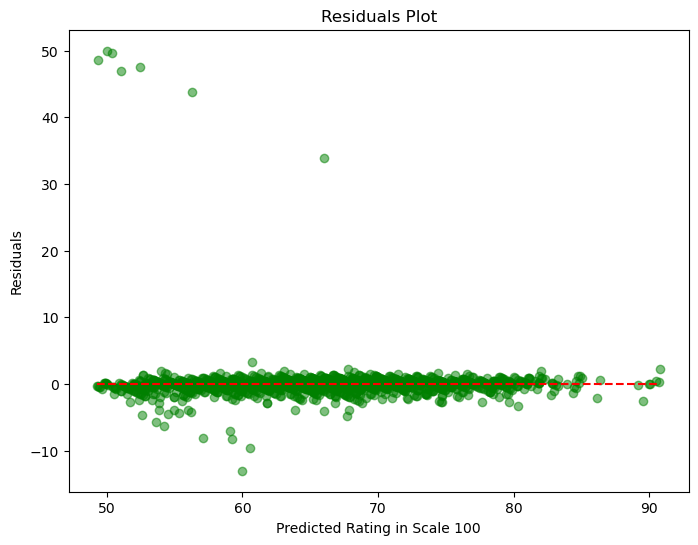

In [27]:
# Calculate residuals (difference between actual and predicted values)
# Residuals = Actual values - Predicted values
residuals_rf = y_test - y_best_pred_rf

# Create a residual plot to visualize the distribution of errors
plt.figure(figsize=(8, 6))  # Set the figure size

# Scatter plot of predicted values vs residuals
plt.scatter(y_best_pred_rf, residuals_rf, alpha=0.5, color='green')  # alpha adjusts the transparency of points
plt.hlines(y=0, xmin=y_best_pred_rf.min(), xmax=y_best_pred_rf.max(), colors='red', linestyles='dashed')  # Horizontal reference line at y=0

# Set labels and title for the plot
plt.xlabel('Predicted Rating in Scale 100')  # X-axis label: Predicted values
plt.ylabel('Residuals')  # Y-axis label: Residuals (prediction errors)
plt.title('Residuals Plot')  # Title of the plot

# Display the plot
plt.show()


<mark><font color=black size=5>**Group Component 2**</font><mark>

<mark><font color=black size=3>**Optimal Model Comparison**</font><mark>

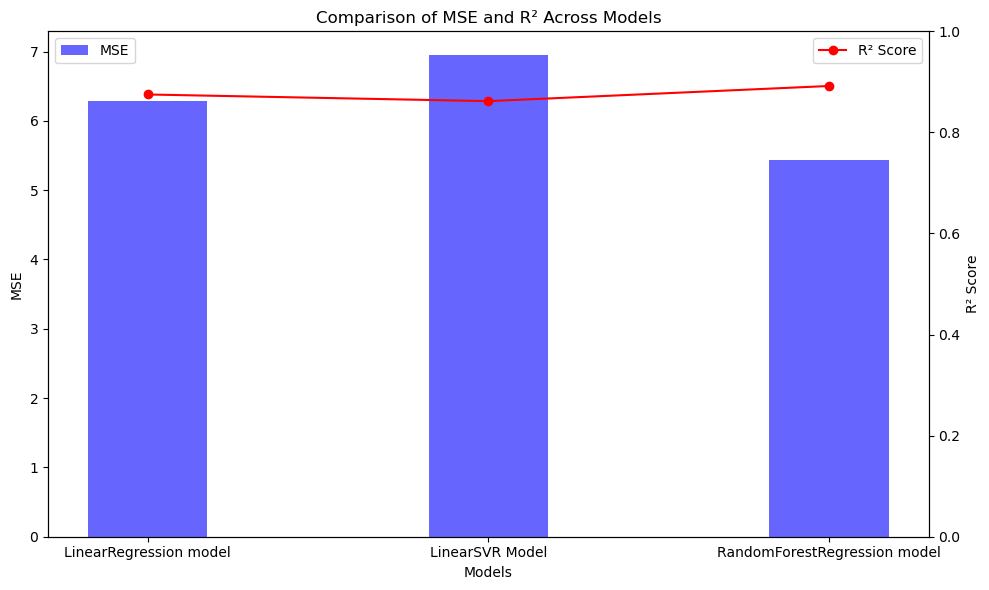

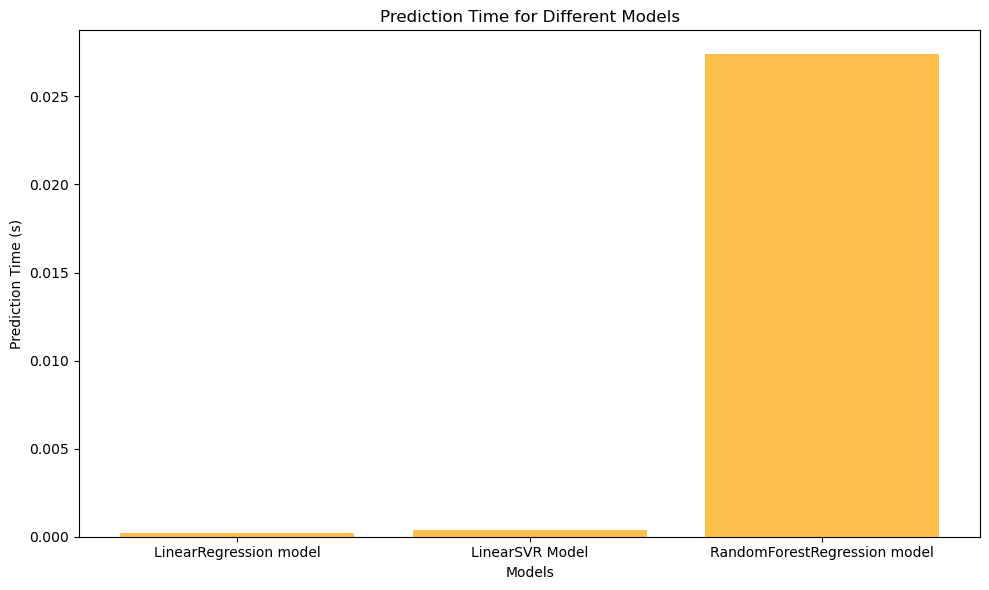

In [30]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

models = ['LinearRegression model', 'LinearSVR Model', 'RandomForestRegression model']
mse_scores = [mse_lr, mse_best_svr, mse_best_rf]
r2_scores = [r2_lr, r2_best_svr, r2_best_rf]
time = [prediction_time_lr, prediction_time_svr, prediction_time_rf]

# Visualizing MSE and R²
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plotting the MSE bar chart
bar_width = 0.35
indices = np.arange(len(models))
bars_mse = ax1.bar(indices, mse_scores, bar_width, label='MSE', color='blue', alpha=0.6)

# Setting labels and title for X and Y axes
ax1.set_xlabel('Models')
ax1.set_ylabel('MSE')
ax1.set_title('Comparison of MSE and R² Across Models')
ax1.set_xticks(indices)
ax1.set_xticklabels(models)
ax1.legend(loc='upper left')

# Creating a second Y-axis and plotting the R² line chart
ax2 = ax1.twinx()
ax2.plot(indices, r2_scores, color='red', marker='o', linestyle='-', label='R² Score')
ax2.set_ylabel('R² Score')

# Setting a new scale for the second Y-axis
ax2.set_ylim([0, 1])
ax2.set_yticks(np.linspace(0, 1, 6))
ax2.legend(loc='upper right')

# Display the figure
plt.tight_layout()
plt.show()

# Visualizing prediction times
plt.figure(figsize=(10, 6))
plt.bar(models, time, color='orange', alpha=0.7)
plt.xlabel('Models')
plt.ylabel('Prediction Time (s)')
plt.title('Prediction Time for Different Models')
plt.tight_layout()
plt.show()

<font color=black size=2>**In the code above, we compared three models. From the visualization results, based on MSE and R², the Random Forest Regression model has the best fit. However, in terms of runtime, the Random Forest Regression model takes much longer compared to LinearSVR and Linear Regression.**</font>

<mark><font color=black size=3>**Final Model Recommendation**</font><mark>

<font color=black size=2>**For this task, since the dataset is not large, the runtime is not very long, and Random Forest achieved a good fit, we consider it the best model. However, if the dataset were larger and runtime was a priority, LinearSVR and Linear Regression would be the models to prioritize.**</font>

<mark><font color=black size=3>**The end of the code**</font><mark>